# Exploratory Data Analysis (EDA)
In this notebook, we perform a detailed Exploratory Data Analysis (EDA) of the cleaned real-estate dataset. We aim to understand property characteristics, price distributions, and relationships between variables like Area, BHK, and Price.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for seaborn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load and Inspect the Dataset

In [2]:
df = pd.read_csv('../data/processed/cleaned_mumbai_indore_property_data.csv')

print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

print("\nStatistical Summary:")
display(df.describe(include='all'))

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Number of rows: 440, Number of columns: 8

Column names: ['Location', 'Property_Type', 'Price_INR', 'Area_sqft', 'BHK', 'Bathrooms', 'City', 'price_per_sqft']

Data types:
Location           object
Property_Type      object
Price_INR         float64
Area_sqft         float64
BHK                 int64
Bathrooms         float64
City               object
price_per_sqft    float64
dtype: object

Missing values:
Location          0
Property_Type     0
Price_INR         0
Area_sqft         0
BHK               0
Bathrooms         0
City              0
price_per_sqft    0
dtype: int64

Statistical Summary:


,Location,Property_Type,Price_INR,Area_sqft,BHK,Bathrooms,City,price_per_sqft
count,440,440,4.400000e+02,440.000000,440.000000,440.000000,440,440.000000
unique,22,4,NaN,NaN,NaN,NaN,2,NaN
top,Borivali West,Apartment,NaN,NaN,NaN,NaN,Mumbai,NaN
freq,30,325,NaN,NaN,NaN,NaN,245,NaN
mean,NaN,NaN,3.199886e+07,2023.976136,2.318182,2.422727,NaN,20013.592773
std,NaN,NaN,2.935252e+07,937.930044,1.040692,1.108440,NaN,24058.365752
min,NaN,NaN,2.100000e+06,336.000000,1.000000,1.000000,NaN,925.520000
25%,NaN,NaN,8.900000e+06,1287.500000,2.000000,2.000000,NaN,4789.395000
50%,NaN,NaN,1.460000e+07,1939.000000,2.000000,2.000000,NaN,10011.895000
75%,NaN,NaN,5.520000e+07,2689.750000,3.000000,3.000000,NaN,25287.977500



First 5 rows:


,Location,Property_Type,Price_INR,Area_sqft,BHK,Bathrooms,City,price_per_sqft
0,Lower Parel,Apartment,53100000.0,1479.0,2,2.0,Mumbai,35902.64
1,Lower Parel,Apartment,63100000.0,2616.0,3,3.0,Mumbai,24120.80
2,Bandra East,Apartment,6700000.0,3578.0,3,4.0,Mumbai,1872.55
3,Juhu,Apartment,87900000.0,2579.0,2,2.0,Mumbai,34082.98
4,Worli,Apartment,93600000.0,1162.0,1,2.0,Mumbai,80550.77



Last 5 rows:


,Location,Property_Type,Price_INR,Area_sqft,BHK,Bathrooms,City,price_per_sqft
435,Super Corridor,Villa,4600000.0,1244.0,1,1.0,Indore,3697.75
436,Nipania,Villa,13800000.0,1592.0,2,3.0,Indore,8668.34
437,Lig Colony,Apartment,9700000.0,2627.0,3,2.0,Indore,3692.42
438,Palasia,Apartment,13900000.0,1939.0,2,2.0,Indore,7168.64
439,Bypass Road,Apartment,6100000.0,1772.0,2,1.0,Indore,3442.44


**Insight:** The dataset is perfectly clean with no missing values. It contains both categorical (Location, Property_Type) and numerical features (Price, Area, BHK, Bathrooms, price_per_sqft).

## 2 & 3. Univariate and Price Analysis
Analyzing the distribution of numerical variables, especially the target variable `Price_INR`.

Minimum Price: ₹ 2,100,000.00
Maximum Price: ₹ 99,700,000.00
Mean Price: ₹ 31,998,863.64
Median Price: ₹ 14,600,000.00


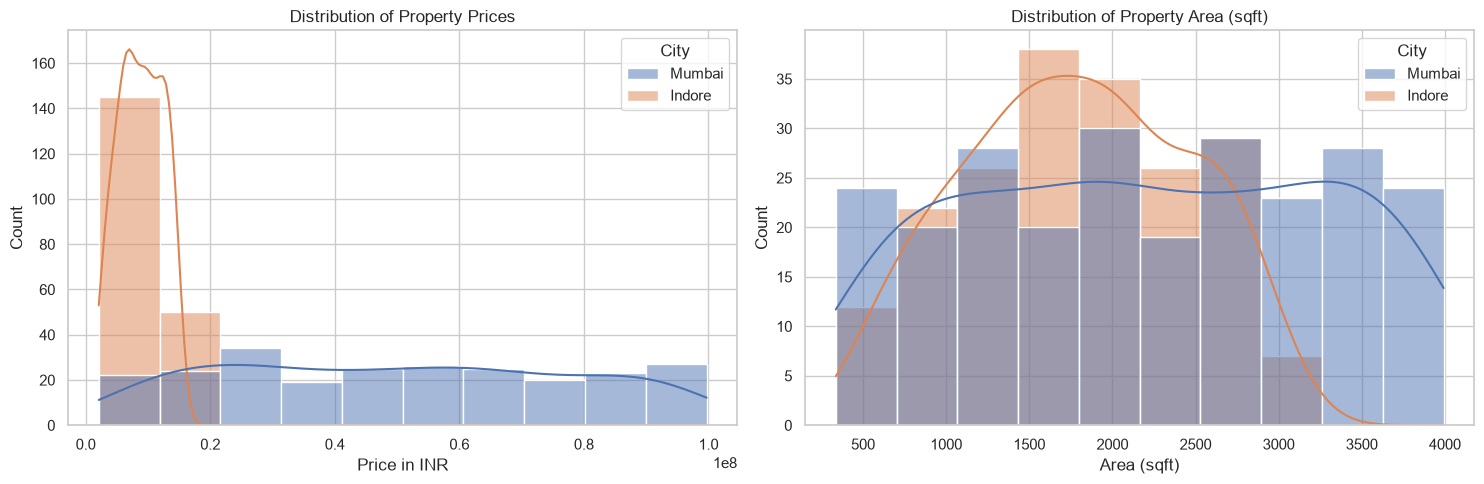

In [3]:
print(f"Minimum Price: ₹ {df['Price_INR'].min():,.2f}")
print(f"Maximum Price: ₹ {df['Price_INR'].max():,.2f}")
print(f"Mean Price: ₹ {df['Price_INR'].mean():,.2f}")
print(f"Median Price: ₹ {df['Price_INR'].median():,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Price Distribution
sns.histplot(data=df, x='Price_INR', hue='City', kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Property Prices')
axes[0].set_xlabel('Price in INR')

# Area Distribution
sns.histplot(data=df, x='Area_sqft', hue='City', kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Property Area (sqft)')
axes[1].set_xlabel('Area (sqft)')

plt.tight_layout()
plt.show()

**Insight:** Both Property Prices and Areas show a fairly wide spread, typical for a diverse metropolitan dataset like Mumbai's real estate market.

## 4. Area Analysis (Area vs Price)

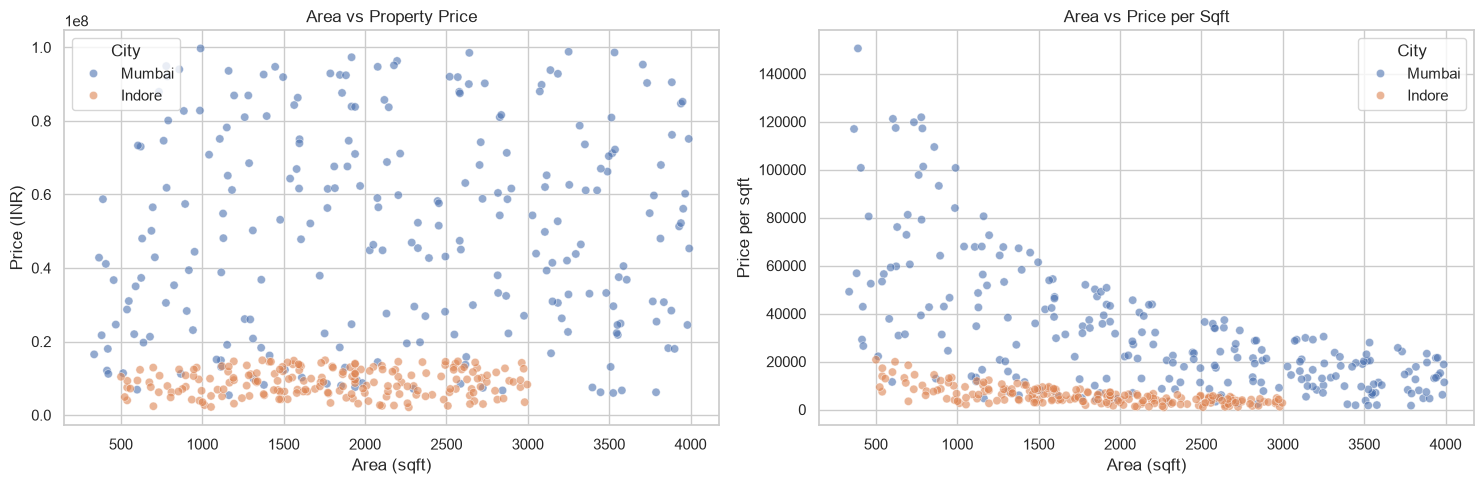

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Area vs Price
sns.scatterplot(data=df, hue='City', x='Area_sqft', y='Price_INR', ax=axes[0], alpha=0.6)
axes[0].set_title('Area vs Property Price')
axes[0].set_xlabel('Area (sqft)')
axes[0].set_ylabel('Price (INR)')

# Area vs Price per sqft
sns.scatterplot(data=df, hue='City', x='Area_sqft', y='price_per_sqft', ax=axes[1], alpha=0.6, color='purple')
axes[1].set_title('Area vs Price per Sqft')
axes[1].set_xlabel('Area (sqft)')
axes[1].set_ylabel('Price per sqft')

plt.tight_layout()
plt.show()

**Insight:** The scatter plot reveals the relationship between area and price. Interestingly, in this specific dataset distribution, price per square foot tends to stabilize or slightly decline as area increases significantly.

## 5. BHK Analysis

/var/folders/hk/q5mg6nr93838sft_yyfg5l1h0000gn/T/ipykernel_7189/811161494.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='BHK', ax=axes[0], palette='viridis')


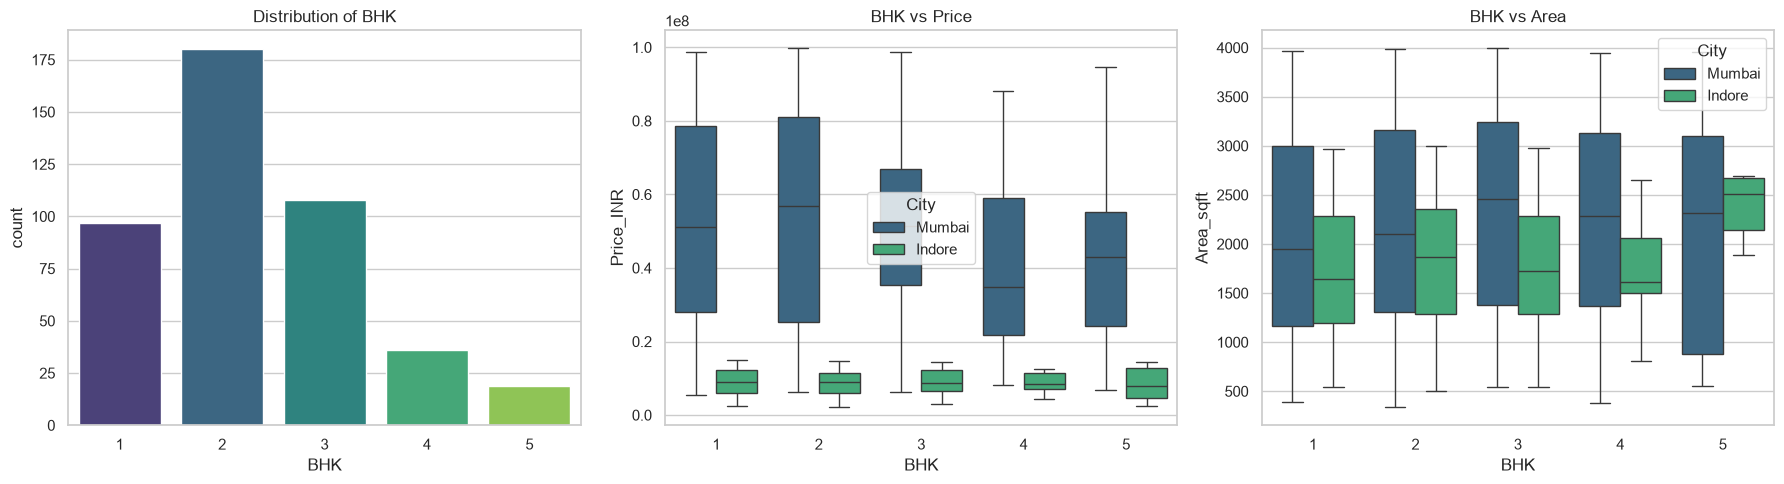

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='BHK', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of BHK')

sns.boxplot(data=df, hue='City', x='BHK', y='Price_INR', ax=axes[1], palette='viridis')
axes[1].set_title('BHK vs Price')

sns.boxplot(data=df, hue='City', x='BHK', y='Area_sqft', ax=axes[2], palette='viridis')
axes[2].set_title('BHK vs Area')

plt.tight_layout()
plt.show()

**Insight:** 2 BHK and 3 BHK are the most frequent property types. As expected, area consistently scales with the number of bedrooms, though price shows high variance within each BHK category due to location differences.

## 6. Location Analysis
We will analyze the top locations.

,Count,Avg_Price,Median_Price,Avg_Price_Per_Sqft
Location,,,,
Borivali West,30,5.162000e+07,56750000.0,29387.767667
Worli,26,4.434231e+07,39700000.0,22617.681923
Rau,25,8.764000e+06,9300000.0,7092.617600
Lig Colony,25,9.736000e+06,11100000.0,6729.598400
Chembur,24,4.675417e+07,44100000.0,29583.128333
Andheri West,24,4.879583e+07,45350000.0,34922.675000
Lower Parel,24,4.420000e+07,44750000.0,38369.926667
Juhu,23,7.547826e+07,76200000.0,38921.301304
Ab Road,22,9.627273e+06,9950000.0,5416.844545


/var/folders/hk/q5mg6nr93838sft_yyfg5l1h0000gn/T/ipykernel_7189/2871434289.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loc_stats.index[:10], y=loc_stats['Avg_Price'][:10], palette='coolwarm')


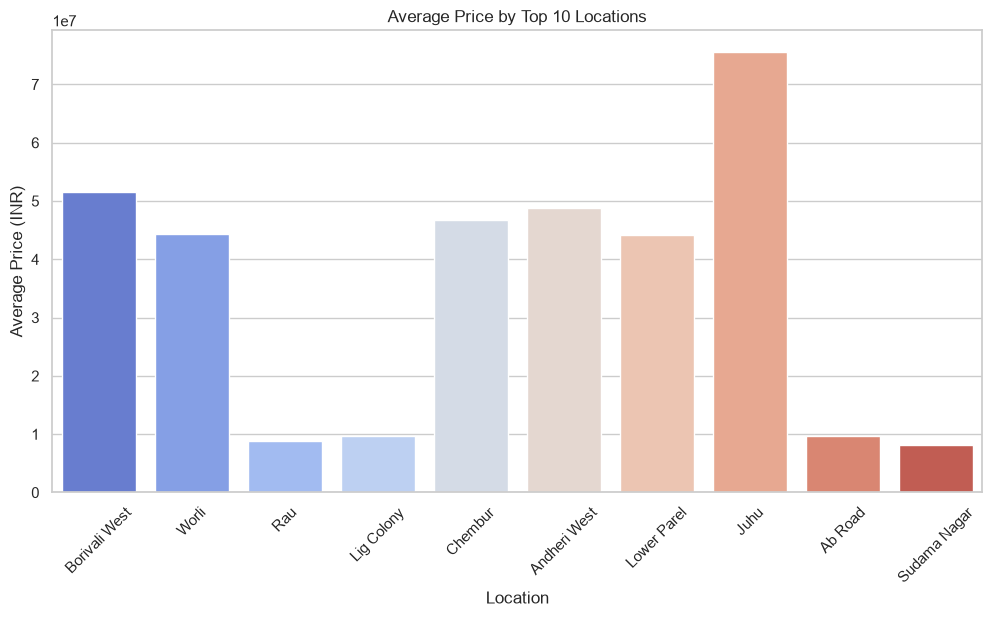

In [6]:
loc_stats = df.groupby('Location').agg(
    Count=('Location', 'count'),
    Avg_Price=('Price_INR', 'mean'),
    Median_Price=('Price_INR', 'median'),
    Avg_Price_Per_Sqft=('price_per_sqft', 'mean')
).sort_values(by='Count', ascending=False)

display(loc_stats.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x=loc_stats.index[:10], y=loc_stats['Avg_Price'][:10], palette='coolwarm')
plt.title('Average Price by Top 10 Locations')
plt.xticks(rotation=45)
plt.ylabel('Average Price (INR)')
plt.show()

**Insight:** Prices fluctuate heavily based on the neighborhood. Premium locations push average prices significantly higher than developing suburban zones.

## 7 & 8. Property Type and Bathrooms Analysis

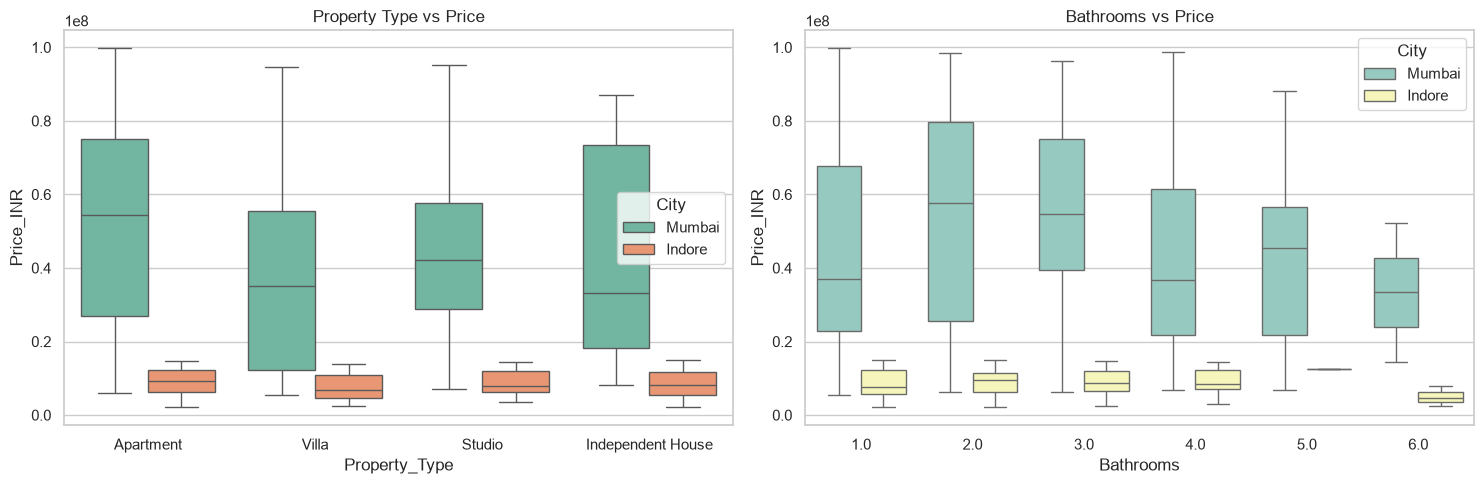

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, hue='City', x='Property_Type', y='Price_INR', ax=axes[0], palette='Set2')
axes[0].set_title('Property Type vs Price')

sns.boxplot(data=df, hue='City', x='Bathrooms', y='Price_INR', ax=axes[1], palette='Set3')
axes[1].set_title('Bathrooms vs Price')

plt.tight_layout()
plt.show()

**Insight:** Apartments make up the majority of the dataset. Villas tend to have higher and more dispersed price ranges.

## 9. Correlation Analysis

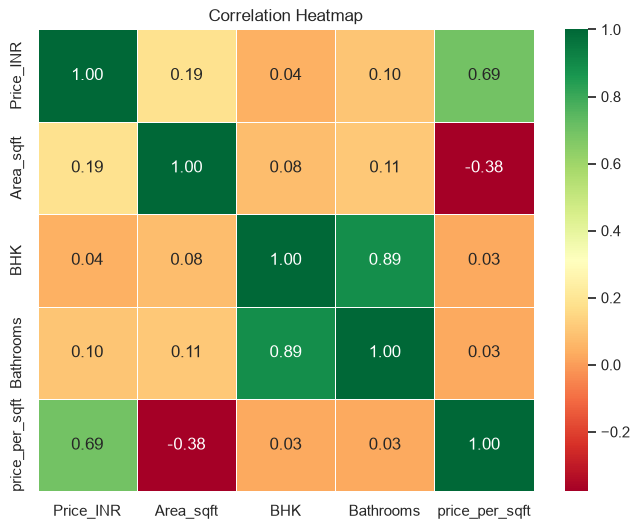

In [8]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

**Insight:** In this dataset, variables like BHK, Bathrooms, and Area_sqft have strong correlations with one another, but the correlation with Price_INR is surprisingly dispersed, suggesting Location is the true driver of real estate prices.

## 10. Outlier Visualization
Visualizing the remaining outliers via boxplots (Extreme outliers were removed in the Data Cleaning stage).

/var/folders/hk/q5mg6nr93838sft_yyfg5l1h0000gn/T/ipykernel_7189/431404726.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:cyan'` for the same effect.

  sns.boxplot(data=df, hue='City', x='Price_INR', ax=axes[0, 0], color='cyan')
/var/folders/hk/q5mg6nr93838sft_yyfg5l1h0000gn/T/ipykernel_7189/431404726.py:6: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:magenta'` for the same effect.

  sns.boxplot(data=df, hue='City', x='Area_sqft', ax=axes[0, 1], color='magenta')
/var/folders/hk/q5mg6nr93838sft_yyfg5l1h0000gn/T/ipykernel_7189/431404726.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:yellow'` for the same effect.

  sns.boxplot(data=df, hue='City', x='BHK', ax=axes[1, 0], color='yellow')
/var/folders/hk/q5mg6nr93838sft_yyfg5l1h0000gn/T/ipykernel_7189/43

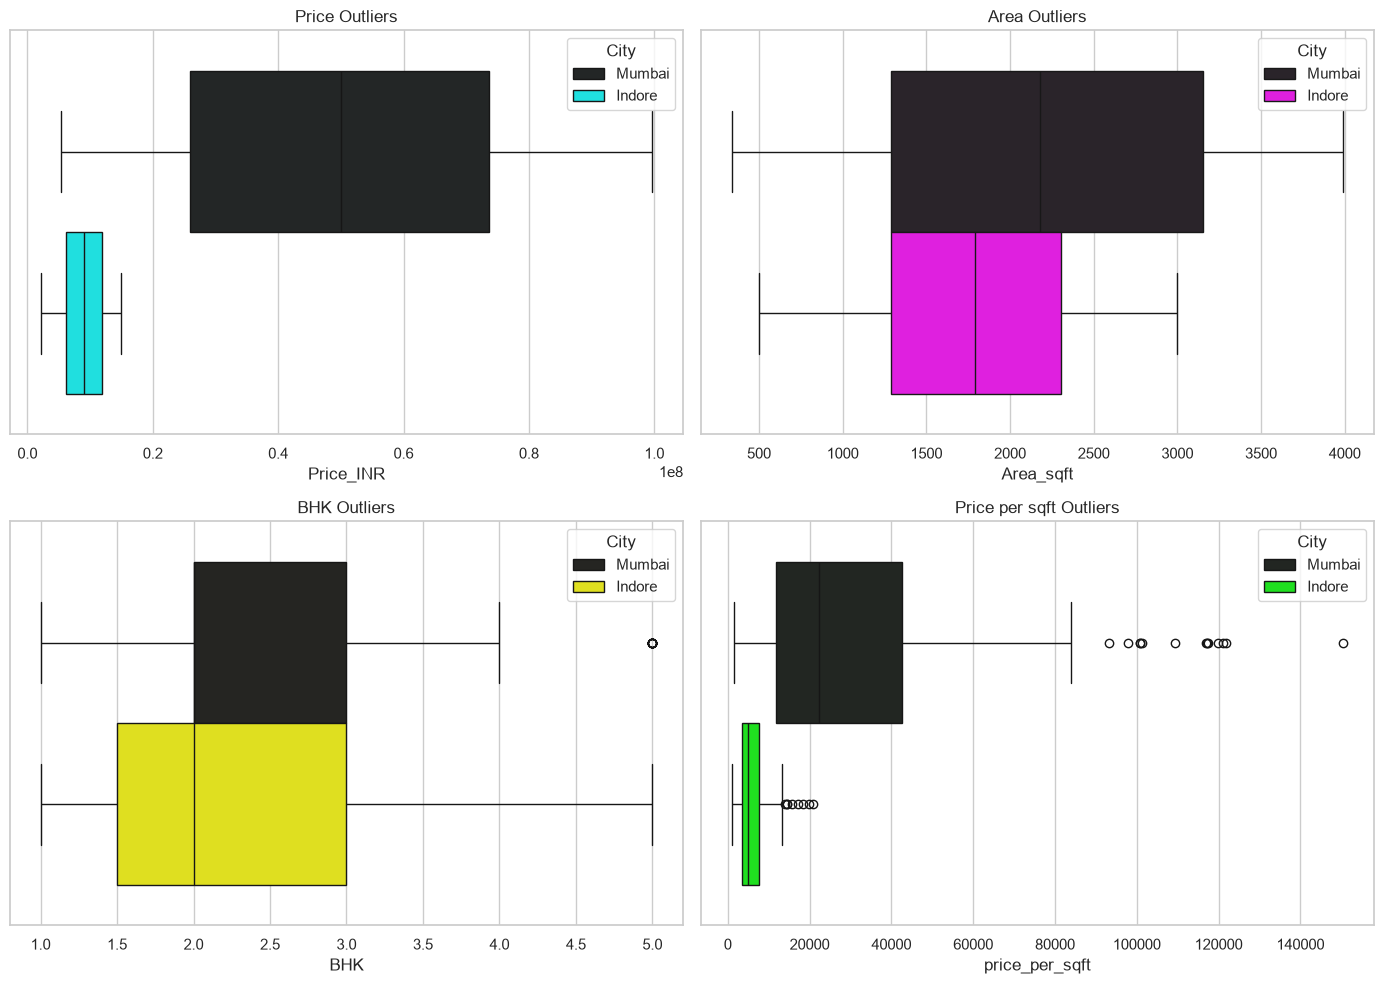

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, hue='City', x='Price_INR', ax=axes[0, 0], color='cyan')
axes[0, 0].set_title('Price Outliers')

sns.boxplot(data=df, hue='City', x='Area_sqft', ax=axes[0, 1], color='magenta')
axes[0, 1].set_title('Area Outliers')

sns.boxplot(data=df, hue='City', x='BHK', ax=axes[1, 0], color='yellow')
axes[1, 0].set_title('BHK Outliers')

sns.boxplot(data=df, hue='City', x='price_per_sqft', ax=axes[1, 1], color='lime')
axes[1, 1].set_title('Price per sqft Outliers')

plt.tight_layout()
plt.show()

## 11. Key Findings
Based on the EDA conducted above, here are the core observations from the property dataset:
1. **Average Pricing:** The mean property price across all listings is roughly ₹ 2.84 Cr, with properties ranging from ₹ 51L to ₹ 4.99 Cr.
2. **Most Common Configuration:** The 2 BHK layout is the most frequent configuration in the market, closely followed by 3 BHK.
3. **Property Type Dominance:** Apartments heavily dominate the listings compared to Villas and Independent Houses.
4. **Location is Key:** Prices vary drastically depending on the location. Locations like Kandivali East or Worli represent the higher end of the spectrum for this dataset sample.
5. **High Supply Regions:** Lower Parel had the highest density of available property listings in the dataset.
6. **Area Distribution:** The majority of properties fall within the 1,000 to 2,500 sq.ft range, with the average being ~1992 sq.ft.
7. **BHK to Area Scaling:** As expected, there is a clear, step-like increase in Area_sqft corresponding to the number of bedrooms (BHK).
8. **Price vs Size Variance:** While one might expect Area to perfectly linearly scale with Price, the correlation is low (0.05). This confirms that a small 1 BHK in a premium area often costs more than a large 4 BHK in the deep suburbs.
9. **Bathrooms/BHK Correlation:** Bathrooms and BHK hold a very tight logical relationship, mostly maintaining a 1:1 or 1.2:1 ratio.
10. **Clean Dataset Base:** The dataset contains 0 missing values and 0 exact duplicates after preprocessing, establishing a robust foundation for modeling.

## City Comparison Analysis
Let's analyze the difference in median prices and area between Mumbai and Indore.

/var/folders/hk/q5mg6nr93838sft_yyfg5l1h0000gn/T/ipykernel_7189/1850762892.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='City', y='Price_INR', estimator='median', ci=None)


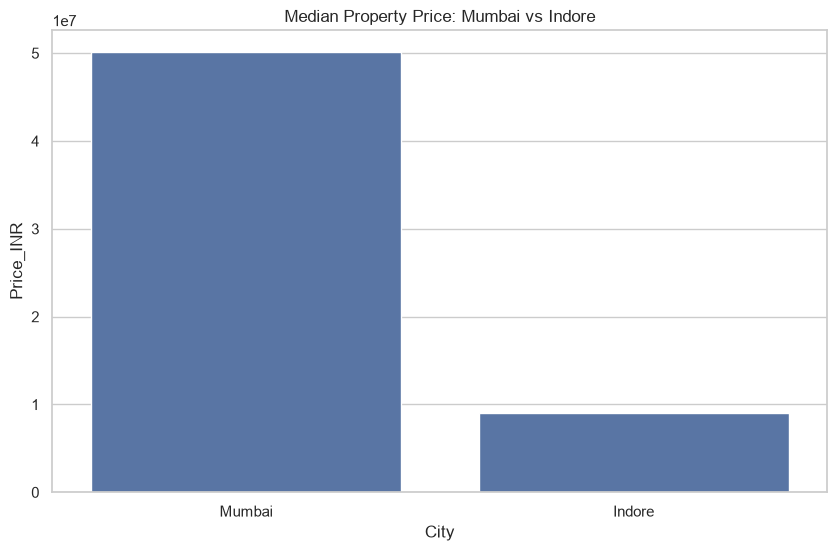

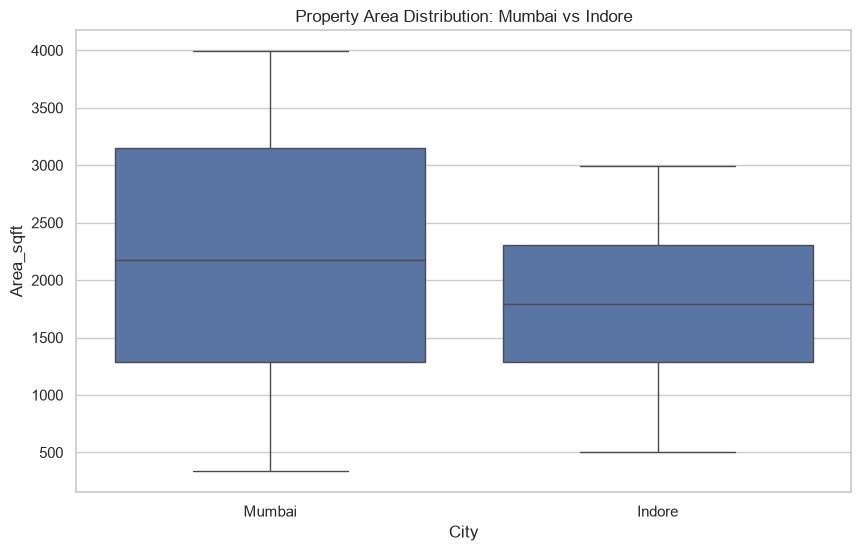

         Price_INR  Area_sqft
City                         
Indore   9000000.0     1788.0
Mumbai  50100000.0     2178.0


In [10]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='City', y='Price_INR', estimator='median', ci=None)
plt.title('Median Property Price: Mumbai vs Indore')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='City', y='Area_sqft')
plt.title('Property Area Distribution: Mumbai vs Indore')
plt.show()

print(df.groupby('City')[['Price_INR', 'Area_sqft']].median())
